## Assignment 2: FedSpeak Analysis

In [1]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
%cd /content/drive/MyDrive/fed-sentiment-analysis/

/content/drive/MyDrive/fed-sentiment-analysis


In [3]:
PROJECT_ROOT = Path(
    "/content/drive/MyDrive/fed-sentiment-analysis"
)

Project exists: True
Contents: ['.gitignore', '.env.example', 'requirements.txt', 'README.md', 'AI_USE.md', '.DS_Store', 'notebooks', 'src', 'outputs', 'report', 'data', 'run_analysis.log', 'forecast.py']


In [ ]:
!touch /content/drive/MyDrive/fed-sentiment-analysis/src/__init__.py

## Collect Data and Run Analysis

Code compiled into modules in src

In [ ]:
!python -m src.collect_fed_documents

In [ ]:
!python -m src.validate_data

In [17]:
from pathlib import Path
PROJECT_ROOT = Path("/content/drive/MyDrive/fed-sentiment-analysis")

SCRIPT_PATH = PROJECT_ROOT / "src/score_lexicon_new.py"
LEXICON_PATH = (
    PROJECT_ROOT
    / "data/processed/component_phrase_lexicon.csv"
)
DOCUMENTS_DIR = PROJECT_ROOT / "data/raw/documents"
SCORES_PATH = (
    PROJECT_ROOT
    / "data/processed/component_lexicon_scores.csv"
)

!python "{SCRIPT_PATH}" \
    --input "{DOCUMENTS_DIR}" \
    --lexicon "{LEXICON_PATH}" \
    --output "{SCORES_PATH}"

In [ ]:
!python -m src.score_finbert

In [ ]:
!python -m src.collect_market_data

In [ ]:
!python -m src.run_analysis

In [18]:
lexicon_scores = pd.read_csv(SCORES_PATH)

SCORE_COLUMNS = [
    "lexicon_interest_rate_score",
    "lexicon_economy_score",
    "lexicon_job_market_score",
    "lexicon_sentiment_score",
    "lexicon_score",
]

display(
    lexicon_scores[
        ["document_id", *SCORE_COLUMNS, "lexicon_total_matches"]
    ].head()
)

display(
    lexicon_scores[SCORE_COLUMNS]
    .describe()
    .round(4)
)

EVENT_PATH = PROJECT_ROOT / "data/processed/event_sample.csv"

events = pd.read_csv(EVENT_PATH)

events["document_id"] = events["document_id"].astype(str)
lexicon_scores["document_id"] = (
    lexicon_scores["document_id"].astype(str)
)

# Remove scores created by the previous lexicon implementation.
old_lexicon_columns = [
    column
    for column in events.columns
    if column.startswith("lexicon_")
]

events = events.drop(
    columns=old_lexicon_columns,
    errors="ignore",
)

# Keep all scores and matching diagnostics.
score_columns = [
    column
    for column in lexicon_scores.columns
    if column.startswith("lexicon_")
]

events = events.merge(
    lexicon_scores[["document_id", *score_columns]],
    on="document_id",
    how="left",
    validate="one_to_one",
)

,document_id,lexicon_interest_rate_score,lexicon_economy_score,lexicon_job_market_score,lexicon_sentiment_score,lexicon_score,lexicon_total_matches
0,00cc0526b055463ba37c,0.000000,-0.014963,0.000000,0.0,-0.003741,7
1,0142ba27f5ade012ab62,0.000000,0.000000,0.000000,0.0,0.000000,0
2,01a6a5da2f4c42bebbd5,-0.033333,0.000000,0.000000,0.0,-0.008333,4
3,0343875e4b5aef678edf,0.000000,0.002946,-0.001473,0.0,0.000368,7
4,03a775a01b6dfbb32acd,0.000000,0.000000,0.000000,0.0,0.000000,0


,lexicon_interest_rate_score,lexicon_economy_score,lexicon_job_market_score,lexicon_sentiment_score,lexicon_score
count,311.0000,311.0000,311.0000,311.0000,311.0000
mean,0.0015,-0.0015,0.0091,0.0014,0.0026
std,0.0112,0.0157,0.0207,0.0128,0.0082
min,-0.0385,-0.0522,-0.0735,-0.0645,-0.0221
25%,0.0000,-0.0038,0.0000,0.0000,-0.0005
50%,0.0000,0.0000,0.0000,0.0000,0.0000
75%,0.0000,0.0008,0.0133,0.0016,0.0049
max,0.0435,0.1000,0.1277,0.1000,0.0500


In [19]:
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


PROJECT_ROOT = Path(
    "/content/drive/MyDrive/fed-sentiment-analysis"
)

EVENT_PATH = (
    PROJECT_ROOT
    / "data/processed/event_sample_new_lexicon.csv"
)

FIGURE_DIR = PROJECT_ROOT / "outputs/figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

WARSH_START = pd.Timestamp("2026-05-22")

events = pd.read_csv(EVENT_PATH)
events["release_date"] = pd.to_datetime(events["release_date"])


# --------------------------------------------------
# Create the three plotting groups
# --------------------------------------------------

CHAIR_TYPES = {
    "press_conference",
    "testimony",
    "speech",
    "speech_or_other",
}

events["plot_group"] = events["document_type"].map(
    {
        "statement": "FOMC Statements",
        "minutes": "FOMC Meeting Minutes",
    }
)

events.loc[
    events["document_type"].isin(CHAIR_TYPES),
    "plot_group",
] = "Chair Communications"

PLOT_GROUPS = [
    "FOMC Statements",
    "FOMC Meeting Minutes",
    "Chair Communications",
]

COLORS = {
    "FOMC Statements": "#0072B2",
    "FOMC Meeting Minutes": "#D55E00",
    "Chair Communications": "#009E73",
}

print(
    events.groupby(
        ["plot_group", "document_type"],
        dropna=False,
        ).size()
)

plot_group            document_type   
Chair Communications  press_conference    66
                      speech              79
                      testimony           27
FOMC Meeting Minutes  minutes             69
FOMC Statements       statement           70
dtype: int64


Maximum blended-score discrepancy: 9.974659986866641e-17


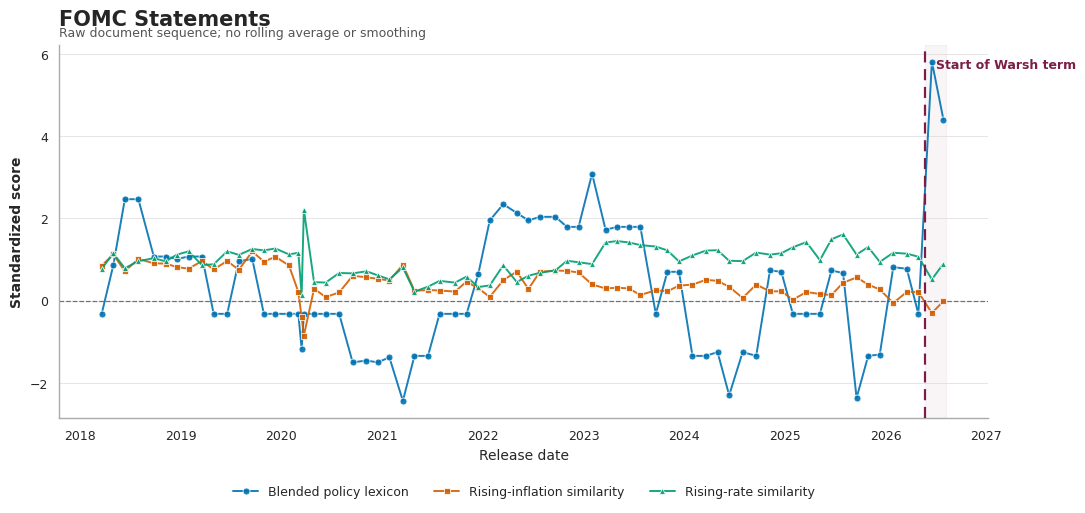

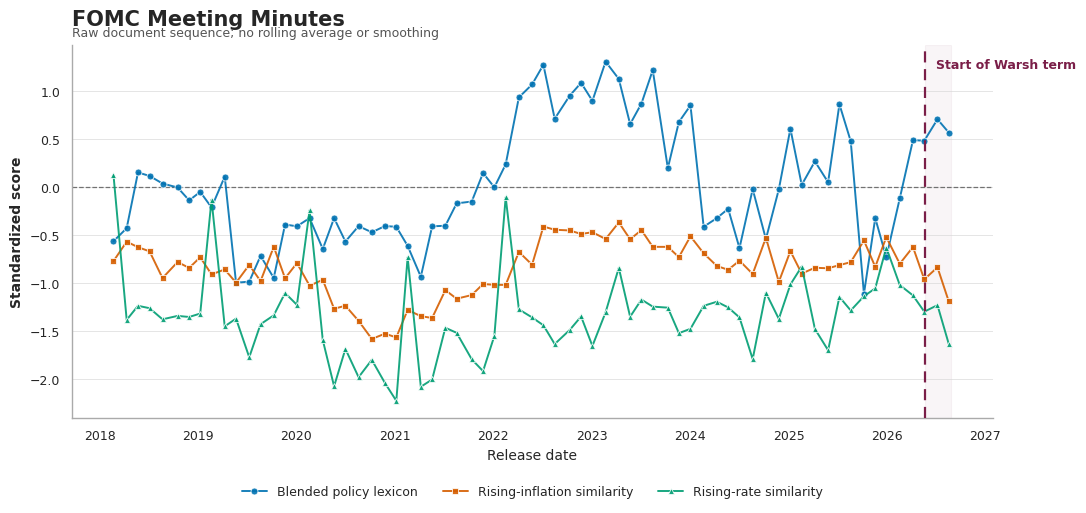

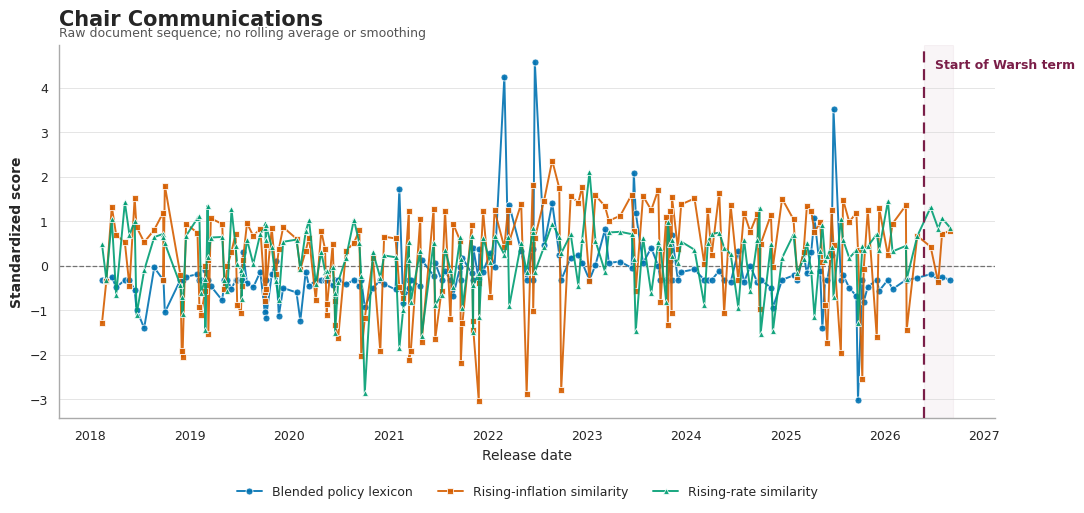

Saved figures:
/content/drive/MyDrive/fed-sentiment-analysis/outputs/figures/blended_tone_fomc_statements.png
/content/drive/MyDrive/fed-sentiment-analysis/outputs/figures/blended_tone_fomc_statements.pdf
/content/drive/MyDrive/fed-sentiment-analysis/outputs/figures/blended_tone_fomc_meeting_minutes.png
/content/drive/MyDrive/fed-sentiment-analysis/outputs/figures/blended_tone_fomc_meeting_minutes.pdf
/content/drive/MyDrive/fed-sentiment-analysis/outputs/figures/blended_tone_chair_communications.png
/content/drive/MyDrive/fed-sentiment-analysis/outputs/figures/blended_tone_chair_communications.pdf


In [21]:
import re

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

EVENT_PATH = (
    PROJECT_ROOT
    / "data/processed/event_sample_new_lexicon.csv"
)

FIGURE_DIR = PROJECT_ROOT / "outputs/figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

WARSH_START = pd.Timestamp("2026-05-22")

TONE_METHODS = {
    "lexicon_score": "Blended policy lexicon",
    "factor_inflation_score": "Rising-inflation similarity",
    "factor_interest_rate_score": "Rising-rate similarity",
}

DOCUMENT_TYPES = {
    "statement": "FOMC Statements",
    "minutes": "FOMC Meeting Minutes",
    "chair_communication": "Chair Communications",
}

COLORS = {
    "Blended policy lexicon": "#0072B2",
    "Rising-inflation similarity": "#D55E00",
    "Rising-rate similarity": "#009E73",
}

MARKERS = {
    "Blended policy lexicon": "o",
    "Rising-inflation similarity": "s",
    "Rising-rate similarity": "^",
}

sns.set_theme(style="whitegrid", context="paper")


events = pd.read_csv(EVENT_PATH)

events["release_date"] = pd.to_datetime(
    events["release_date"]
)


# Recreate document_group if it is not already present.
if "document_group" not in events.columns:
    events["document_group"] = events["document_type"].map(
        {
            "statement": "statement",
            "minutes": "minutes",
            "press_conference": "chair_communication",
            "testimony": "chair_communication",
            "speech": "chair_communication",
            "speech_or_other": "chair_communication",
        }
    )

COMPONENT_COLUMNS = [
    "lexicon_interest_rate_score",
    "lexicon_economy_score",
    "lexicon_job_market_score",
    "lexicon_sentiment_score",
]

required_columns = [
    *COMPONENT_COLUMNS,
    "lexicon_score",
    "factor_inflation_score",
    "factor_interest_rate_score",
]

missing_columns = [
    column
    for column in required_columns
    if column not in events.columns
]

if missing_columns:
    raise KeyError(
        f"Missing required columns: {missing_columns}"
    )

calculated_blend = events[COMPONENT_COLUMNS].mean(axis=1)

maximum_difference = (
    calculated_blend - events["lexicon_score"]
).abs().max()

print(
    "Maximum blended-score discrepancy:",
    maximum_difference,
)

if maximum_difference > 1e-10:
    print(
        "Recalculating lexicon_score as the equal-weight "
        "mean of the four category scores."
    )

    events["lexicon_score"] = calculated_blend

# Standardize each method across the full sample

plot_data = events.copy()

for column in TONE_METHODS:
    mean = plot_data[column].mean()
    std = plot_data[column].std(ddof=0)

    plot_data[f"{column}_z"] = np.where(
        std > 0,
        (plot_data[column] - mean) / std,
        0.0,
    )


id_vars = [
    column
    for column in [
        "document_id",
        "release_date",
        "document_group",
        "document_type",
        "chair",
        "title",
    ]
    if column in plot_data.columns
]

long_data = plot_data.melt(
    id_vars=id_vars,
    value_vars=[
        f"{column}_z"
        for column in TONE_METHODS
    ],
    var_name="tone_column",
    value_name="tone_z",
)

long_data["score_column"] = (
    long_data["tone_column"]
    .str.removesuffix("_z")
)

long_data["method"] = (
    long_data["score_column"]
    .map(TONE_METHODS)
)

# Plotting function


def safe_filename(value):
    return re.sub(
        r"[^a-z0-9]+",
        "_",
        value.lower(),
    ).strip("_")


def plot_document_tone(
    data,
    document_group,
    display_name,
):
    subset = (
        data.loc[
            data["document_group"].eq(document_group)
        ]
        .dropna(
            subset=[
                "release_date",
                "tone_z",
                "method",
            ]
        )
        .sort_values("release_date")
        .copy()
    )

    if subset.empty:
        print(
            f"No observations found for {display_name}"
        )
        return None

    fig, ax = plt.subplots(
        figsize=(11, 5.8)
    )

    for method in TONE_METHODS.values():
        method_data = (
            subset.loc[
                subset["method"].eq(method)
            ]
            .sort_values("release_date")
        )

        ax.plot(
            method_data["release_date"],
            method_data["tone_z"],
            color=COLORS[method],
            linewidth=1.4,
            alpha=0.9,
            marker=MARKERS[method],
            markersize=5,
            markerfacecolor=COLORS[method],
            markeredgecolor="white",
            markeredgewidth=0.6,
            label=method,
            zorder=3,
        )

    # Standardized full-sample mean
    ax.axhline(
        0,
        color="#555555",
        linewidth=0.9,
        linestyle="--",
        alpha=0.8,
    )

    # Beginning of the Warsh term
    ax.axvline(
        WARSH_START,
        color="#7A1E48",
        linewidth=1.6,
        linestyle=(0, (5, 3)),
        zorder=4,
    )

    ax.axvspan(
        WARSH_START,
        subset["release_date"].max()
        + pd.Timedelta(days=10),
        color="#7A1E48",
        alpha=0.045,
        zorder=0,
    )

    ax.annotate(
        "Start of Warsh term",
        xy=(WARSH_START, 1),
        xycoords=("data", "axes fraction"),
        xytext=(8, -10),
        textcoords="offset points",
        color="#7A1E48",
        fontsize=9,
        fontweight="semibold",
        ha="left",
        va="top",
    )

    ax.set_title(
        display_name,
        fontsize=15,
        fontweight="bold",
        loc="left",
        pad=14,
    )

    ax.text(
        0,
        1.015,
        (
            "Raw document sequence; "
            "no rolling average or smoothing"
        ),
        transform=ax.transAxes,
        fontsize=9,
        color="#555555",
        ha="left",
        va="bottom",
    )

    ax.set_ylabel(
        "Standardized score",
        fontsize=10,
        fontweight="semibold",
    )
    ax.set_xlabel(
        "Release date",
        fontsize=10,
    )

    ax.legend(
        title=None,
        frameon=False,
        ncol=3,
        loc="upper center",
        bbox_to_anchor=(0.5, -0.15),
        fontsize=9,
    )

    ax.grid(
        axis="y",
        color="#D9D9D9",
        linewidth=0.7,
        alpha=0.7,
    )
    ax.grid(axis="x", visible=False)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("#AAAAAA")
    ax.spines["bottom"].set_color("#AAAAAA")

    ax.tick_params(
        axis="both",
        labelsize=9,
    )

    fig.tight_layout(
        rect=[0, 0.08, 1, 1]
    )

    filename = safe_filename(display_name)

    png_path = (
        FIGURE_DIR
        / f"blended_tone_{filename}.png"
    )

    pdf_path = (
        FIGURE_DIR
        / f"blended_tone_{filename}.pdf"
    )

    fig.savefig(
        png_path,
        dpi=300,
        bbox_inches="tight",
        facecolor="white",
    )

    fig.savefig(
        pdf_path,
        bbox_inches="tight",
        facecolor="white",
    )

    plt.show()

    return png_path, pdf_path

# Generate the three plots

saved_files = []

for document_group, display_name in DOCUMENT_TYPES.items():
    result = plot_document_tone(
        long_data,
        document_group=document_group,
        display_name=display_name,
    )

    if result is not None:
        saved_files.append(result)

print("Saved figures:")

for png_path, pdf_path in saved_files:
    print(png_path)
    print(pdf_path)

## Building table with 1 day change in metrics

In [4]:
TABLE_DIR = PROJECT_ROOT / "outputs/tables"
TABLE_DIR.mkdir(parents=True, exist_ok=True)

WARSH_START = pd.Timestamp("2026-05-22")

events = pd.read_csv(EVENT_PATH)
events["release_date"] = pd.to_datetime(
    events["release_date"]
)


LEXICON_COMPONENTS = [
    "lexicon_interest_rate_score",
    "lexicon_economy_score",
    "lexicon_job_market_score",
    "lexicon_sentiment_score",
]

missing_components = [
    column
    for column in LEXICON_COMPONENTS
    if column not in events.columns
]

if missing_components:
    raise KeyError(
        f"Missing lexicon components: {missing_components}"
    )

events["lexicon_score"] = (
    events[LEXICON_COMPONENTS].mean(axis=1)
)

MATCH_COLUMNS = [
    "lexicon_interest_rate_signature_matches",
    "lexicon_economy_signature_matches",
    "lexicon_job_market_signature_matches",
    "lexicon_sentiment_signature_matches",
]

available_match_columns = [
    column
    for column in MATCH_COLUMNS
    if column in events.columns
]

if (
    "lexicon_total_matches" not in events.columns
    and available_match_columns
):
    events["lexicon_total_matches"] = (
        events[available_match_columns].sum(axis=1)
    )

requested_columns = [
    "release_date",
    "release_time_et",
    "document_type",
    "title",

    # Professor-style lexicon
    "lexicon_interest_rate_score",
    "lexicon_economy_score",
    "lexicon_job_market_score",
    "lexicon_sentiment_score",
    "lexicon_score",
    "lexicon_total_matches",

    # FinBERT embedding similarity
    "factor_inflation_score",
    "factor_interest_rate_score",

    # Market changes
    "dxy_change_pct",
    "spread_10s2s_change_bp",
    "dgs1_change_bp",
    "growth_minus_value_pct",
]

available_columns = [
    column
    for column in requested_columns
    if column in events.columns
]

missing_columns = [
    column
    for column in requested_columns
    if column not in events.columns
]

if missing_columns:
    print(
        "Columns not available and omitted:",
        missing_columns,
    )

table_2 = (
    events.loc[
        events["release_date"].ge(WARSH_START),
        available_columns,
    ]
    .sort_values(
        ["release_date", "release_time_et"],
        ascending=[True, True],
    )
    .reset_index(drop=True)
)


DISPLAY_NAMES = {
    "release_date": "Release date",
    "release_time_et": "Release time (ET)",
    "document_type": "Document type",
    "title": "Title",

    "lexicon_interest_rate_score": (
        "Interest-rate lexicon"
    ),
    "lexicon_economy_score": (
        "Economy lexicon"
    ),
    "lexicon_job_market_score": (
        "Job-market lexicon"
    ),
    "lexicon_sentiment_score": (
        "Sentiment lexicon"
    ),
    "lexicon_score": (
        "Blended lexicon"
    ),
    "lexicon_total_matches": (
        "Lexicon matches"
    ),

    "factor_inflation_score": (
        "Inflation similarity"
    ),
    "factor_interest_rate_score": (
        "Rate similarity"
    ),

    "dxy_change_pct": "DXY (%)",
    "spread_10s2s_change_bp": "10s2s (bp)",
    "dgs1_change_bp": "1Y Treasury (bp)",
    "growth_minus_value_pct": (
        "Growth − value (%)"
    ),
}

table_2_display = table_2.rename(
    columns=DISPLAY_NAMES
)

table_2_display["Release date"] = (
    table_2_display["Release date"]
    .dt.strftime("%Y-%m-%d")
)


# ============================================================
# Save the raw machine-readable table
# ============================================================

output_path = (
    TABLE_DIR
    / "table_2_warsh_documents_new_lexicon.csv"
)

table_2.to_csv(
    output_path,
    index=False,
)


# ============================================================
# Styled display
# ============================================================

numeric_columns = [
    column
    for column in table_2_display.columns
    if column not in {
        "Release date",
        "Release time (ET)",
        "Document type",
        "Title",
        "Lexicon matches",
    }
]

format_dictionary = {
    column: "{:.4f}"
    for column in numeric_columns
}

if "Lexicon matches" in table_2_display.columns:
    format_dictionary["Lexicon matches"] = "{:.0f}"

styled_table_2 = (
    table_2_display.style
    .format(
        format_dictionary,
        na_rep="—",
    )
    .set_properties(
        **{
            "text-align": "left",
            "font-size": "9pt",
        }
    )
    .set_properties(
        subset=numeric_columns,
        **{
            "text-align": "right",
        }
    )
    .set_table_styles(
        [
            {
                "selector": "th",
                "props": [
                    ("background-color", "#D9E1F2"),
                    ("font-weight", "bold"),
                    ("text-align", "center"),
                    ("border", "1px solid #AAAAAA"),
                ],
            },
            {
                "selector": "td",
                "props": [
                    ("border", "1px solid #DDDDDD"),
                    ("padding", "5px"),
                ],
            },
        ]
    )
)

print(
    f"Table 2 contains {len(table_2)} "
    "Warsh-era documents."
)

display(styled_table_2)

print(f"Saved: {output_path}")

Table 2 contains 8 Warsh-era documents.


,Release date,Release time (ET),Document type,Title,Interest-rate lexicon,Economy lexicon,Job-market lexicon,Sentiment lexicon,Blended lexicon,Lexicon matches,Inflation similarity,Rate similarity,DXY (%),10s2s (bp),1Y Treasury (bp),Growth − value (%)
0,2026-06-17,14:00,statement,Federal Reserve issues FOMC statement,0.0000,0.1000,0.0000,0.1000,0.0500,3,0.4190,0.5598,0.5525,-9.0000,14.0000,-0.2578
1,2026-06-17,14:30,press_conference,FOMC Press Conference - 2026-06-17,0.0000,0.0021,0.0000,0.0021,0.0011,3,0.4362,0.5861,0.5525,-9.0000,14.0000,-0.2578
2,2026-07-08,10:00,minutes,"FOMC Minutes, June 16-17, 2026",0.0000,0.0210,0.0000,0.0126,0.0084,16,0.4065,0.5019,-0.0890,-1.0000,0.0000,1.5063
3,2026-07-15,09:00,testimony,Testimony by Chairman Warsh on the semiannual Monetary Policy Report to Congress,0.0000,0.0000,0.0000,0.0000,0.0000,0,0.4173,0.5703,-0.4359,2.0000,-5.0000,-0.4856
4,2026-07-29,14:00,statement,Federal Reserve issues FOMC statement,0.0000,0.0769,0.0000,0.0769,0.0385,3,0.4259,0.5726,-0.5721,10.0000,-5.0000,-0.9662
5,2026-07-29,14:30,press_conference,FOMC Press Conference - 2026-07-29,0.0000,0.0021,0.0000,0.0000,0.0005,2,0.4430,0.5780,-0.5721,10.0000,-5.0000,-0.9662
6,2026-08-19,10:00,minutes,"FOMC Minutes, July 28–29, 2026",0.0000,0.0182,-0.0036,0.0145,0.0073,16,0.3981,0.4885,-0.8229,-6.0000,1.0000,-0.8418
7,2026-08-28,09:00,speech,Keynote remarks by Chairman Warsh at the 2026 Jackson Hole Economic Policy Symposium,0.0000,0.0000,0.0000,0.0000,0.0000,0,0.4446,0.5710,0.5446,-8.0000,11.0000,-0.2082


Saved: /content/drive/MyDrive/fed-sentiment-analysis/outputs/tables/table_2_warsh_documents_new_lexicon.csv


## Regression with 3MO control and results

In [5]:
import statsmodels.api as sm

events = pd.read_csv(EVENT_PATH)


# ============================================================
# Reconstruct blended score if necessary
# ============================================================

LEXICON_COMPONENTS = [
    "lexicon_interest_rate_score",
    "lexicon_economy_score",
    "lexicon_job_market_score",
    "lexicon_sentiment_score",
]

missing_components = [
    column
    for column in LEXICON_COMPONENTS
    if column not in events.columns
]

if missing_components:
    raise KeyError(
        f"Missing lexicon components: {missing_components}"
    )

events["lexicon_score"] = (
    events[LEXICON_COMPONENTS].mean(axis=1)
)


# ============================================================
# Regression configuration
# ============================================================

TONE_METHODS = {
    "lexicon_score": "Blended policy lexicon",
    "factor_inflation_score": "Rising-inflation similarity",
    "factor_interest_rate_score": "Rising-rate similarity",
}

OUTCOMES = {
    "dxy_change_pct": "DXY (%)",
    "spread_10s2s_change_bp": "10s2s (bp)",
    "dgs1_change_bp": "1Y Treasury (bp)",
    "growth_minus_value_pct": "Growth - value (%)",
}

CONTROL = "dgs3mo_change_bp"

required_columns = [
    *TONE_METHODS,
    *OUTCOMES,
    CONTROL,
]

missing_columns = [
    column
    for column in required_columns
    if column not in events.columns
]

if missing_columns:
    raise KeyError(
        f"Missing regression columns: {missing_columns}"
    )


def significance_stars(p_value):
    if p_value < 0.01:
        return "***"
    if p_value < 0.05:
        return "**"
    if p_value < 0.10:
        return "*"
    return ""


# Main regressions:
# one tone method at a time + DGS3MO control


main_results = []

for outcome_column, outcome_label in OUTCOMES.items():
    for tone_column, tone_label in TONE_METHODS.items():

        regression_data = (
            events[
                [
                    outcome_column,
                    tone_column,
                    CONTROL,
                ]
            ]
            .replace([np.inf, -np.inf], np.nan)
            .dropna()
            .astype(float)
        )

        y = regression_data[outcome_column]

        X = sm.add_constant(
            regression_data[
                [tone_column, CONTROL]
            ],
            has_constant="add",
        )

        model = sm.OLS(y, X).fit(
            cov_type="HC1"
        )

        coefficient = model.params[tone_column]
        robust_se = model.bse[tone_column]
        t_statistic = model.tvalues[tone_column]
        p_value = model.pvalues[tone_column]

        main_results.append(
            {
                "indicator": outcome_label,
                "tone_method": tone_label,
                "tone_column": tone_column,
                "tone_coefficient": coefficient,
                "robust_se": robust_se,
                "t_statistic": t_statistic,
                "p_value": p_value,
                "significance": significance_stars(
                    p_value
                ),
                "dgs3mo_coefficient": (
                    model.params[CONTROL]
                ),
                "dgs3mo_robust_se": (
                    model.bse[CONTROL]
                ),
                "dgs3mo_p_value": (
                    model.pvalues[CONTROL]
                ),
                "r_squared": model.rsquared,
                "n": int(model.nobs),
            }
        )

main_table = pd.DataFrame(main_results)

main_path = (
    TABLE_DIR
    / "table_3_regressions_new_lexicon.csv"
)

main_table.to_csv(
    main_path,
    index=False,
)


# ============================================================
# Professor-style regressions:
# four category scores entered jointly + DGS3MO
# ============================================================

joint_results = []

for outcome_column, outcome_label in OUTCOMES.items():

    regression_data = (
        events[
            [
                outcome_column,
                CONTROL,
                *LEXICON_COMPONENTS,
            ]
        ]
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
        .astype(float)
    )

    y = regression_data[outcome_column]

    X = sm.add_constant(
        regression_data[
            [
                *LEXICON_COMPONENTS,
                CONTROL,
            ]
        ],
        has_constant="add",
    )

    model = sm.OLS(y, X).fit(
        cov_type="HC1"
    )

    for component in LEXICON_COMPONENTS:
        coefficient = model.params[component]
        robust_se = model.bse[component]
        t_statistic = model.tvalues[component]
        p_value = model.pvalues[component]

        joint_results.append(
            {
                "indicator": outcome_label,
                "lexicon_component": component,
                "coefficient": coefficient,
                "robust_se": robust_se,
                "t_statistic": t_statistic,
                "p_value": p_value,
                "significance": significance_stars(
                    p_value
                ),
                "dgs3mo_coefficient": (
                    model.params[CONTROL]
                ),
                "dgs3mo_robust_se": (
                    model.bse[CONTROL]
                ),
                "dgs3mo_p_value": (
                    model.pvalues[CONTROL]
                ),
                "r_squared": model.rsquared,
                "n": int(model.nobs),
            }
        )

joint_table = pd.DataFrame(joint_results)

joint_path = (
    TABLE_DIR
    / "table_3_lexicon_categories_joint.csv"
)

joint_table.to_csv(
    joint_path,
    index=False,
)


# ============================================================
# Formatted display
# ============================================================

display_columns = [
    "indicator",
    "tone_method",
    "tone_coefficient",
    "robust_se",
    "t_statistic",
    "p_value",
    "significance",
    "dgs3mo_coefficient",
    "dgs3mo_p_value",
    "r_squared",
    "n",
]

print("MAIN REGRESSIONS")
display(
    main_table[display_columns]
    .style
    .format(
        {
            "tone_coefficient": "{:.4f}",
            "robust_se": "{:.4f}",
            "t_statistic": "{:.3f}",
            "p_value": "{:.4f}",
            "dgs3mo_coefficient": "{:.4f}",
            "dgs3mo_p_value": "{:.4f}",
            "r_squared": "{:.4f}",
            "n": "{:.0f}",
        }
    )
    .map(
        lambda value: (
            "background-color: #D9EAD3; "
            "font-weight: bold"
            if value < 0.05
            else (
                "background-color: #FFF2CC"
                if value < 0.10
                else ""
            )
        ),
        subset=["p_value"],
    )
)

print("\nJOINT LEXICON-CATEGORY REGRESSIONS")
display(
    joint_table[
        [
            "indicator",
            "lexicon_component",
            "coefficient",
            "robust_se",
            "t_statistic",
            "p_value",
            "significance",
            "r_squared",
            "n",
        ]
    ]
    .style
    .format(
        {
            "coefficient": "{:.4f}",
            "robust_se": "{:.4f}",
            "t_statistic": "{:.3f}",
            "p_value": "{:.4f}",
            "r_squared": "{:.4f}",
            "n": "{:.0f}",
        }
    )
    .map(
        lambda value: (
            "background-color: #D9EAD3; "
            "font-weight: bold"
            if value < 0.05
            else (
                "background-color: #FFF2CC"
                if value < 0.10
                else ""
            )
        ),
        subset=["p_value"],
    )
)

print("\nSaved:")
print(main_path)
print(joint_path)

MAIN REGRESSIONS


,indicator,tone_method,tone_coefficient,robust_se,t_statistic,p_value,significance,dgs3mo_coefficient,dgs3mo_p_value,r_squared,n
0,DXY (%),Blended policy lexicon,-0.3162,2.7747,-0.114,0.9093,,0.0373,0.0000,0.0663,311
1,DXY (%),Rising-inflation similarity,-1.1146,1.1078,-1.006,0.3144,,0.0360,0.0000,0.0699,311
2,DXY (%),Rising-rate similarity,-0.8177,0.6719,-1.217,0.2236,,0.0358,0.0000,0.0701,311
3,10s2s (bp),Blended policy lexicon,-33.7932,31.6701,-1.067,0.2860,,-0.3876,0.0000,0.0854,311
4,10s2s (bp),Rising-inflation similarity,-10.4288,9.1803,-1.136,0.2560,,-0.4022,0.0000,0.0844,311
5,10s2s (bp),Rising-rate similarity,-8.1910,6.9625,-1.176,0.2394,,-0.4045,0.0000,0.0851,311
6,1Y Treasury (bp),Blended policy lexicon,27.2195,34.7424,0.783,0.4334,,0.8636,0.0000,0.2776,311
7,1Y Treasury (bp),Rising-inflation similarity,-0.6888,11.8493,-0.058,0.9536,,0.8648,0.0000,0.2755,311
8,1Y Treasury (bp),Rising-rate similarity,-7.3140,6.5177,-1.122,0.2618,,0.8527,0.0000,0.2779,311
9,Growth - value (%),Blended policy lexicon,16.9302,7.7873,2.174,0.0297,**,0.0088,0.6741,0.0134,311



JOINT LEXICON-CATEGORY REGRESSIONS


,indicator,lexicon_component,coefficient,robust_se,t_statistic,p_value,significance,r_squared,n
0,DXY (%),lexicon_interest_rate_score,-4.1090,2.4000,-1.712,0.0869,*,0.0951,311
1,DXY (%),lexicon_economy_score,-0.6027,1.3399,-0.450,0.6528,,0.0951,311
2,DXY (%),lexicon_job_market_score,-0.5018,1.0602,-0.473,0.6360,,0.0951,311
3,DXY (%),lexicon_sentiment_score,4.6419,1.5954,2.910,0.0036,***,0.0951,311
4,10s2s (bp),lexicon_interest_rate_score,-24.9275,25.5558,-0.975,0.3294,,0.0949,311
5,10s2s (bp),lexicon_economy_score,15.9136,13.7077,1.161,0.2457,,0.0949,311
6,10s2s (bp),lexicon_job_market_score,-5.9947,10.6328,-0.564,0.5729,,0.0949,311
7,10s2s (bp),lexicon_sentiment_score,-24.2912,20.0725,-1.210,0.2262,,0.0949,311
8,1Y Treasury (bp),lexicon_interest_rate_score,-32.3586,28.4751,-1.136,0.2558,,0.3020,311
9,1Y Treasury (bp),lexicon_economy_score,7.6310,12.9592,0.589,0.5560,,0.3020,311



Saved:
/content/drive/MyDrive/fed-sentiment-analysis/outputs/tables/table_3_regressions_new_lexicon.csv
/content/drive/MyDrive/fed-sentiment-analysis/outputs/tables/table_3_lexicon_categories_joint.csv


In [23]:
%cd /content/drive/MyDrive/fed-sentiment-analysis

!git init
!git branch -M main

!git config user.name "Shreya Volety"
!git config user.email "volety.shreya@gmail.com"

/content/drive/MyDrive/fed-sentiment-analysis
hint: Using 'master' as the name for the initial branch. This default branch name
hint: is subject to change. To configure the initial branch name to use in all
hint: of your new repositories, which will suppress this warning, call:
hint: 
hint: 	git config --global init.defaultBranch <name>
hint: 
hint: Names commonly chosen instead of 'master' are 'main', 'trunk' and
hint: 'development'. The just-created branch can be renamed via this command:
hint: 
hint: 	git branch -m <name>
Initialized empty Git repository in /content/drive/MyDrive/fed-sentiment-analysis/.git/


In [24]:
%%writefile .gitignore
# Credentials
.env
*.pem
*.key
credentials.json
token.json

# Raw and proprietary data
data/raw/
data/external/
documents/
*.zip

# Generated/intermediate data
data/interim/
data/processed/
outputs/
*.parquet
*.pkl
*.pickle

# Models and caches
.cache/
__pycache__/
*.pyc
.ipynb_checkpoints/
huggingface/
models/

# OS files
.DS_Store

Overwriting .gitignore


In [29]:
!git status --short

?? .env.example
?? .gitignore
?? AI_USE.md
?? Assignment2-sv3101.ipynb
?? README.md
?? requirements.txt
?? run_analysis.log
?? src/


/content/drive/MyDrive/fed-sentiment-analysis
